<a href="https://colab.research.google.com/github/JeromeJV/-BMC-prelim-lab-exam-/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

messy_data = {
    'patient_name': ['Dela Cruz', 'Santos', 'Reyes', 'bautista', 'GARCIA ', ' Mendoza', 'Torres', 'Ramos',
        'Aquino', 'Fernandez', 'delaCruz', 'Santos', 'Villanueva', 'Domingo', 'Castro',
        None, 'Reyes', 'Navarro', None, 'Pascual', 'Torres', 'Aquino', 'Bautista', 'Cruz', 'Mercado'],
    'sex': ['M','F','Male','female','M','F','m','F','M','Female','F','M','F','M','F',
        'M','F','M','F','M','F','M','F','M','F'],
    'barangay': ['San Roque','Bagumbayan','san roque','Poblacion','Bagumbayan ','San Jose',
        'Poblacion','Sto. Nino','San Roque','Bagumbayan','Poblacion','San Jose',
        'Sto Nino','San Roque','Bagumbayan','Poblacion','San Roque','San Jose',
        'Bagumbayan','Poblacion','Sto. Nino','San Roque','San Jose','Bagumbayan','Poblacion'],
    'visit_date': ['2026-01-05','01/06/2026','2026-1-7','2026-01-08','08-01-2026','2026-01-09',
        '2026-01-09','2026/01/10','2026-01-11','01-12-2026','2026-01-13','2026-01-13',
        '2026-01-14','2026-01-15',None,'2026-01-16','2026-01-17','2026-01-18',
        '2026-01-19','2026-01-20','2026-01-20','2026-01-21','2026-01-22','2026-01-23','2026-01-24'],
    'age': [34, 5, 150, 27, np.nan, 62, 41, 8, np.nan, 29, 34, 5, 71, 45, 19, -3, 55, np.nan, 22, 38, 41, np.nan, 60, 34, 47],
    'weight_kg': ['65kg','18.5','58 kg','70.2','80','45.0kg', '150', '20', '55.5', '62', '65kg', '18.5',
        '68', '75', np.nan, '-40', '90kg', '52', '30', '77', '68', '58', '95', '65kg', '61'],
    'height_cm': [165, 110, 170, np.nan, 175, 150, 168, 128, 160, 172, 165, 110, 155, 180, 140,
        169, 158, np.nan, 132, 162, 168, 173, 5.9, 165, 159],
    'bp_systolic': ['120','95','210','130','118','160','122','100','300','125','120','95','140',
        '135','108','119','150','127','98','131','122','128','145','120','133'],
    'temperature_c': [36.5, 37.0, 39.8, 36.7, 36.6, 38.2, 36.9, 36.8, 42.5, 36.5, 36.5, 37.0,
        37.1, 36.4, 36.9, 36.6, 40.1, 36.7, 36.8, 36.9, 36.5, 37.2, 39.0, 36.5, 36.6],
    'diagnosis': ['Hypertension','Common Cold','hypertension','Diabetes','COMMON COLD','Flu',
        'Hypertension ','Asthma','Diabetes Type 2','common cold','Hypertension','Common Cold',
        'Migraine','Flu','UTI','Hypertension','diabetes','Asthma','Common Cold','Flu',
        'Hypertension','Diabetes','Migrain','Hypertension','UTI'],
    'follow_up_needed': ['Yes','No','yes','NO','Y','N','Yes','No','yes','No','Yes','No','No',
        'Yes','No','Yes','yes','No','N','Yes','Yes','No','Y','Yes','No'],
    'senior_citizen': [0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0]
}

In [2]:
df = pd.DataFrame(messy_data)

In [3]:
df_clean = df.copy()

In [4]:
df_clean['patient_name'] = df_clean['patient_name'].astype(str).str.strip().str.title().replace({'None': np.nan, 'Nan': np.nan})
df_clean['sex'] = df_clean['sex'].str.strip().str.upper().map({'M': 'Male', 'MALE': 'Male', 'F': 'Female', 'FEMALE': 'Female'})
df_clean['barangay'] = df_clean['barangay'].str.strip().str.title().replace({'Sto. Nino': 'Sto. Niño', 'Sto Nino': 'Sto. Niño'})
df_clean['diagnosis'] = df_clean['diagnosis'].str.strip().str.title().replace({'Migrain': 'Migraine', 'Diabetes Type 2': 'Diabetes'})
df_clean['follow_up_needed'] = df_clean['follow_up_needed'].str.strip().str.upper().map({'YES': 'Yes', 'Y': 'Yes', 'NO': 'No', 'N': 'No'})

In [5]:
df_clean['visit_date'] = pd.to_datetime(df_clean['visit_date'], format='mixed', errors='coerce')

In [6]:
df_clean['weight_kg'] = pd.to_numeric(df_clean['weight_kg'].astype(str).str.replace('kg', '').str.strip(), errors='coerce')
df_clean['height_cm'] = pd.to_numeric(df_clean['height_cm'], errors='coerce')
df_clean.loc[df_clean['height_cm'] < 50, 'height_cm'] = df_clean['height_cm']
df_clean['bp_systolic'] = pd.to_numeric(df_clean['bp_systolic'], errors='coerce')

In [7]:
df_clean.loc[(df_clean['age'] < 0) | (df_clean['age'] > 120), 'age'] = np.nan
df_clean.loc[(df_clean['weight_kg'] < 0) | (df_clean['weight_kg'] > 250), 'weight_kg'] = np.nan
df_clean.loc[(df_clean['bp_systolic'] < 50) | (df_clean['bp_systolic'] > 250), 'bp_systolic'] = np.nan

In [8]:
df_clean = df_clean.sort_values('visit_date').reset_index(drop=True)

/tmp/ipykernel_4123/2420098104.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='diagnosis', palette='viridis')


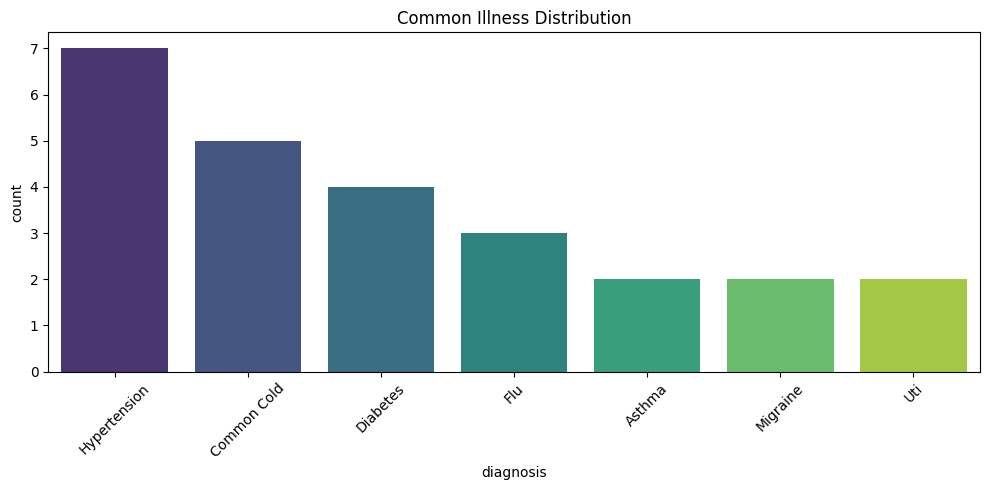

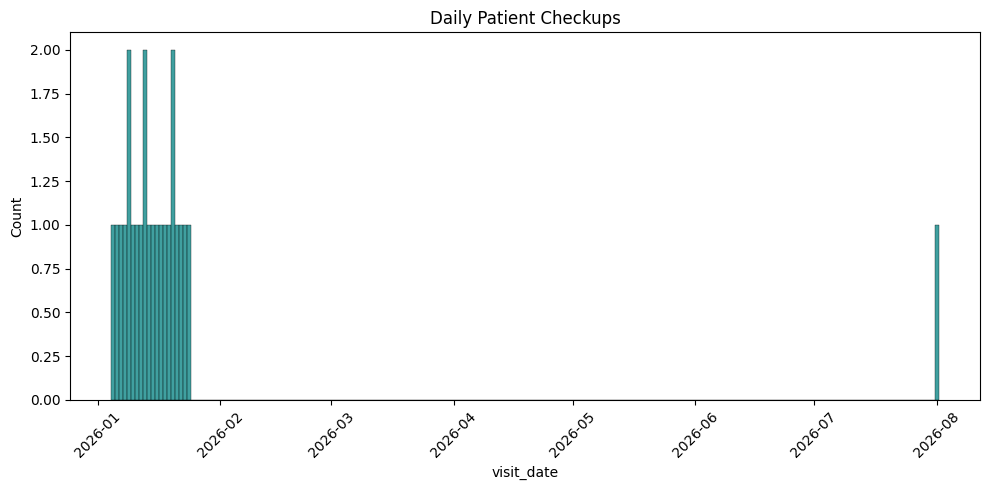

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='diagnosis', palette='viridis')
plt.title('Common Illness Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['visit_date'].dt.date, bins=14, kde=False, color='teal')
plt.title('Daily Patient Checkups')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
print("--- CLEANED DATASET PREVIEW ---")
print(df_clean.head())

--- CLEANED DATASET PREVIEW ---
  patient_name     sex    barangay visit_date   age  weight_kg  height_cm  \
0    Dela Cruz    Male   San Roque 2026-01-05  34.0       65.0      165.0   
1       Santos  Female  Bagumbayan 2026-01-06   5.0       18.5      110.0   
2        Reyes    Male   San Roque 2026-01-07   NaN       58.0      170.0   
3     Bautista  Female   Poblacion 2026-01-08  27.0       70.2        NaN   
4      Mendoza  Female    San Jose 2026-01-09  62.0       45.0      150.0   

   bp_systolic  temperature_c     diagnosis follow_up_needed  senior_citizen  
0        120.0           36.5  Hypertension              Yes               0  
1         95.0           37.0   Common Cold               No               0  
2        210.0           39.8  Hypertension              Yes               1  
3        130.0           36.7      Diabetes               No               0  
4        160.0           38.2           Flu               No               1  
